# Notebook 10: Data Augmentation & Class Weights

## Objectif
Préparer la stratégie d'augmentation et calculer les class weights pour gérer le déséquilibre des classes:
- Analyser le déséquilibre des classes (16.7:1 ratio CMD vs CBB)
- Calculer les class weights avec sklearn
- Définir la stratégie d'augmentation pour classes minoritaires
- Tester les transformations sur échantillons
- Visualiser les résultats

## Dataset Status
- **Total images**: 30,491
- **Déséquilibre**: CMD (59.5%) vs CBB (3.6%) = **16.7:1 ratio**
- **Classes minoritaires**: CBB (1,087 images), CGM (2,386 images)
- **Classes majoritaires**: CMD (18,136 images)

## Stratégie
- **Weighted Loss**: Compenser le déséquilibre pendant l'entraînement
- **Data Augmentation**: Augmenter artificiellement les classes minoritaires
- **Target**: Améliorer F1-score des classes minoritaires de >90%

## 1. Imports & Setup

In [1]:
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuration des paths
PROJECT_ROOT = Path("/home/hounfodjidagba/learning/cassava")
VLM_DATASET_DIR = PROJECT_ROOT / "outputs" / "vlm_dataset"
IMAGES_DIR = VLM_DATASET_DIR / "images"  # Chemin vers les images
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "augmentation_weights"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Style des plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("CONFIGURATION")
print("="*70)
print(f"Dataset directory: {VLM_DATASET_DIR}")
print(f"Images directory: {IMAGES_DIR}")
print(f"Output directory: {OUTPUTS_DIR}")
print("="*70)

CONFIGURATION
Dataset directory: /home/hounfodjidagba/learning/cassava/outputs/vlm_dataset
Images directory: /home/hounfodjidagba/learning/cassava/outputs/vlm_dataset/images
Output directory: /home/hounfodjidagba/learning/cassava/outputs/augmentation_weights


## 2. Chargement des Métadonnées du Dataset

In [2]:
# Charger dataset_info.json
dataset_info_path = VLM_DATASET_DIR / "dataset_info.json"
with open(dataset_info_path, 'r') as f:
    dataset_info = json.load(f)

# Charger class_mapping.json
class_mapping_path = VLM_DATASET_DIR / "class_mapping.json"
with open(class_mapping_path, 'r') as f:
    class_mapping = json.load(f)

print("="*70)
print("INFORMATIONS DU DATASET")
print("="*70)
print(f"Total images: {dataset_info['total_images']:,}")
print(f"Nombre de classes: {dataset_info['num_classes']}")
print("\nClasses:")
for class_name, info in dataset_info['class_distribution'].items():
    print(f"  {class_name}: {info['name']}")
print("="*70)

INFORMATIONS DU DATASET
Total images: 30,491
Nombre de classes: 5

Classes:
  CBB: Cassava Bacterial Blight (CBB)
  CBSD: Cassava Brown Streak Disease (CBSD)
  CGM: Cassava Green Mottle (CGM)
  CMD: Cassava Mosaic Disease (CMD)
  Healthy: Healthy


## 3. Analyse du Déséquilibre des Classes

Analyser en détail la distribution des classes pour comprendre l'ampleur du déséquilibre.

In [3]:
print("="*70)
print("ANALYSE DU DÉSÉQUILIBRE DES CLASSES")
print("="*70)

# Extraire les comptes par classe
class_counts = {}
class_names = {}
for class_short, info in dataset_info['class_distribution'].items():
    class_counts[class_short] = info['count']
    class_names[class_short] = info['name']

# Calculer les statistiques
total = sum(class_counts.values())
min_class = min(class_counts, key=class_counts.get)
max_class = max(class_counts, key=class_counts.get)
imbalance_ratio = class_counts[max_class] / class_counts[min_class]

print(f"\nStatistiques:")
print(f"  - Total images: {total:,}")
print(f"  - Classe majoritaire: {max_class} ({class_counts[max_class]:,} images, {class_counts[max_class]/total*100:.1f}%)")
print(f"  - Classe minoritaire: {min_class} ({class_counts[min_class]:,} images, {class_counts[min_class]/total*100:.1f}%)")
print(f"  - Ratio de déséquilibre: {imbalance_ratio:.1f}:1")

print(f"\nDistribution détaillée:")
for class_short in sorted(class_counts.keys()):
    count = class_counts[class_short]
    percentage = count / total * 100
    bar = '█' * int(percentage)
    print(f"  {class_short:8s} {count:6,} ({percentage:5.1f}%) {bar}")

print("\n⚠️ IMPACT DU DÉSÉQUILIBRE:")
print(f"  - Sans weighted loss, le modèle va être biaisé vers {max_class}")
print(f"  - Les classes minoritaires ({min_class}, CGM) risquent d'être sous-représentées")
print(f"  - F1-score des classes minoritaires sera faible sans correction")
print("="*70)

ANALYSE DU DÉSÉQUILIBRE DES CLASSES

Statistiques:
  - Total images: 30,491
  - Classe majoritaire: CMD (18,136 images, 59.5%)
  - Classe minoritaire: CBB (1,087 images, 3.6%)
  - Ratio de déséquilibre: 16.7:1

Distribution détaillée:
  CBB       1,087 (  3.6%) ███
  CBSD      5,186 ( 17.0%) █████████████████
  CGM       2,386 (  7.8%) ███████
  CMD      18,136 ( 59.5%) ███████████████████████████████████████████████████████████
  Healthy   3,696 ( 12.1%) ████████████

⚠️ IMPACT DU DÉSÉQUILIBRE:
  - Sans weighted loss, le modèle va être biaisé vers CMD
  - Les classes minoritaires (CBB, CGM) risquent d'être sous-représentées
  - F1-score des classes minoritaires sera faible sans correction


## 4. Visualisation de la Distribution

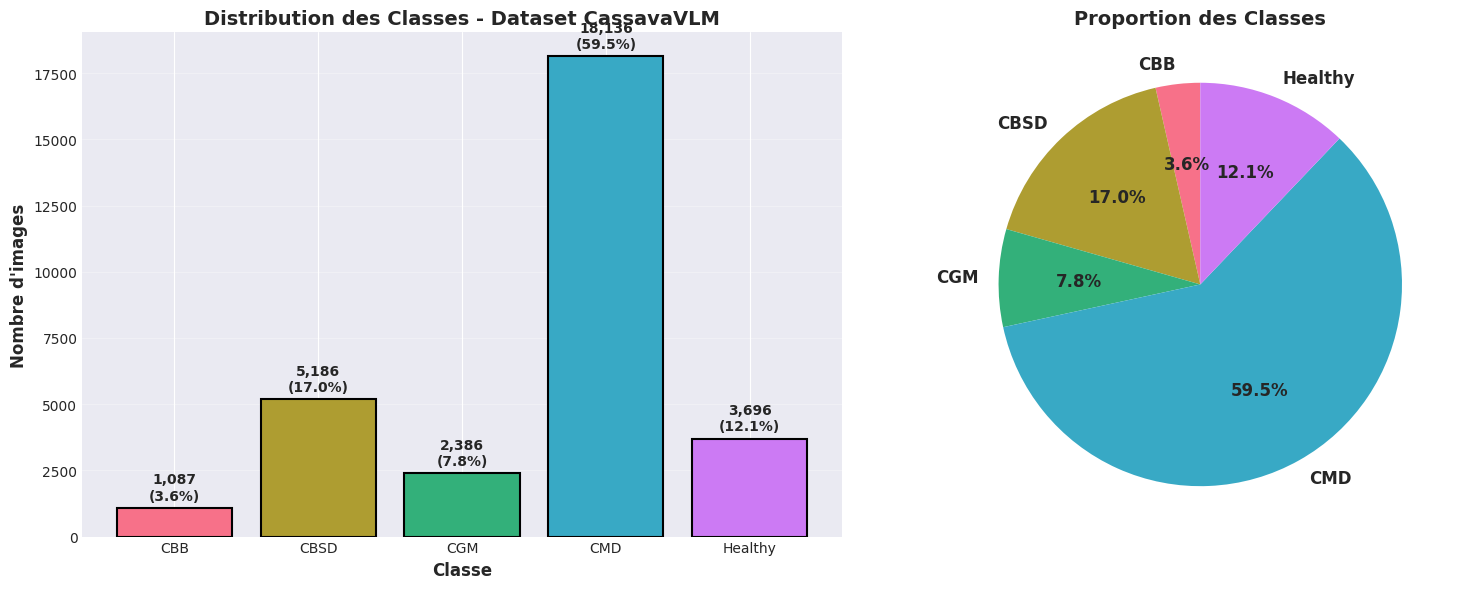

✓ Visualisation sauvegardée: /home/hounfodjidagba/learning/cassava/outputs/augmentation_weights/class_distribution.png


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
classes = list(class_counts.keys())
counts = [class_counts[c] for c in classes]
colors = sns.color_palette("husl", len(classes))

ax1.bar(classes, counts, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Classe', fontsize=12, fontweight='bold')
ax1.set_ylabel('Nombre d\'images', fontsize=12, fontweight='bold')
ax1.set_title('Distribution des Classes - Dataset CassavaVLM', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (cls, count) in enumerate(zip(classes, counts)):
    percentage = count / total * 100
    ax1.text(i, count + 200, f'{count:,}\n({percentage:.1f}%)', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Pie chart
ax2.pie(counts, labels=classes, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Proportion des Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Visualisation sauvegardée: {OUTPUTS_DIR / 'class_distribution.png'}")

## 5. Calcul des Class Weights

Utiliser sklearn pour calculer les poids de classes équilibrés.

In [5]:
print("="*70)
print("CALCUL DES CLASS WEIGHTS")
print("="*70)

# Préparer les labels pour sklearn
# Créer un array avec tous les labels
all_labels = []
for class_short, info in dataset_info['class_distribution'].items():
    label = info['label']
    count = info['count']
    all_labels.extend([label] * count)

all_labels = np.array(all_labels)
unique_labels = np.unique(all_labels)

# Calculer les class weights avec sklearn
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=all_labels
)

print("\nClass Weights (balanced):")
print("\n{:^10s} {:^30s} {:^10s} {:^12s}".format(
    "Label", "Classe", "Count", "Weight"
))
print("="*70)

weight_dict = {}
for label, weight in zip(unique_labels, class_weights):
    # Trouver le nom de la classe
    for class_short, info in dataset_info['class_distribution'].items():
        if info['label'] == label:
            class_name = info['name']
            count = info['count']
            weight_dict[label] = weight
            print("{:^10d} {:^30s} {:^10,} {:^12.4f}".format(
                label, class_name[:28], count, weight
            ))
            break

print("\n" + "="*70)
print("INTERPRÉTATION:")
print("="*70)
min_weight_label = min(weight_dict, key=weight_dict.get)
max_weight_label = max(weight_dict, key=weight_dict.get)
print(f"  - Poids le plus faible: Label {min_weight_label} (classe majoritaire CMD)")
print(f"  - Poids le plus élevé: Label {max_weight_label} (classe minoritaire CBB)")
print(f"  - Ratio des poids: {weight_dict[max_weight_label]/weight_dict[min_weight_label]:.1f}:1")
print(f"\n  ℹ️ Les poids plus élevés pour les classes minoritaires compensent")
print(f"     le déséquilibre pendant l'entraînement via weighted loss.")
print("="*70)

# Convertir en tensor PyTorch
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(f"\n✓ Class weights tensor créé: {class_weights_tensor}")

CALCUL DES CLASS WEIGHTS

Class Weights (balanced):

  Label                Classe               Count       Weight   
    0       Cassava Bacterial Blight (CB    1,087       5.6101   
    1       Cassava Brown Streak Disease    5,186       1.1759   
    2        Cassava Green Mottle (CGM)     2,386       2.5558   
    3       Cassava Mosaic Disease (CMD)    18,136      0.3362   
    4                 Healthy               3,696       1.6499   

INTERPRÉTATION:
  - Poids le plus faible: Label 3 (classe majoritaire CMD)
  - Poids le plus élevé: Label 0 (classe minoritaire CBB)
  - Ratio des poids: 16.7:1

  ℹ️ Les poids plus élevés pour les classes minoritaires compensent
     le déséquilibre pendant l'entraînement via weighted loss.

✓ Class weights tensor créé: tensor([5.6101, 1.1759, 2.5558, 0.3362, 1.6499])


## 6. Visualisation des Class Weights

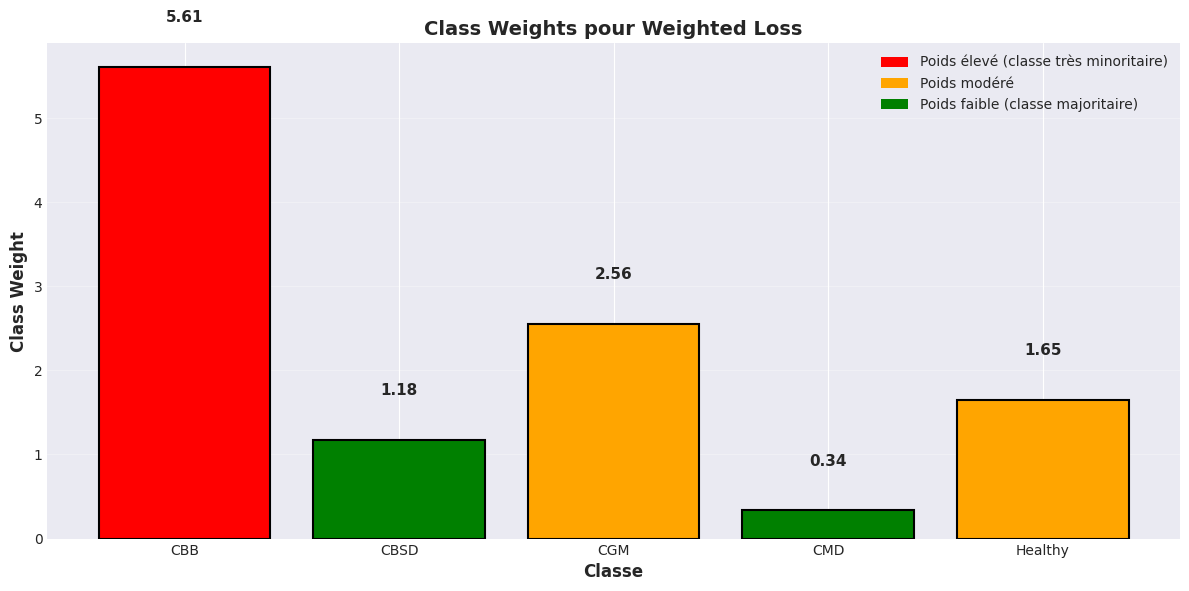

✓ Visualisation sauvegardée: /home/hounfodjidagba/learning/cassava/outputs/augmentation_weights/class_weights.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

labels_list = []
weights_list = []
for label in sorted(unique_labels):
    for class_short, info in dataset_info['class_distribution'].items():
        if info['label'] == label:
            labels_list.append(class_short)
            weights_list.append(weight_dict[label])
            break

colors = ['red' if w == max(weights_list) else 'orange' if w > 1.5 else 'green' 
          for w in weights_list]

bars = ax.bar(labels_list, weights_list, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Classe', fontsize=12, fontweight='bold')
ax.set_ylabel('Class Weight', fontsize=12, fontweight='bold')
ax.set_title('Class Weights pour Weighted Loss', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Ajouter les valeurs
for bar, weight in zip(bars, weights_list):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{weight:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='Poids élevé (classe très minoritaire)'),
    Patch(facecolor='orange', label='Poids modéré'),
    Patch(facecolor='green', label='Poids faible (classe majoritaire)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'class_weights.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Visualisation sauvegardée: {OUTPUTS_DIR / 'class_weights.png'}")

## 7. Stratégie d'Augmentation

Définir les transformations d'augmentation pour les classes minoritaires.

In [7]:
print("="*70)
print("STRATÉGIE D'AUGMENTATION")
print("="*70)

augmentation_strategy = {
    'description': 'Augmentation pour classes minoritaires (CBB, CGM)',
    'target_classes': ['CBB', 'CGM'],  # Classes avec <10% de représentation
    'techniques': [
        {
            'name': 'Rotation',
            'description': 'Rotation aléatoire ±15°',
            'parameters': {'degrees': 15},
            'probability': 0.5
        },
        {
            'name': 'Horizontal Flip',
            'description': 'Retournement horizontal',
            'parameters': {},
            'probability': 0.5
        },
        {
            'name': 'Vertical Flip',
            'description': 'Retournement vertical',
            'parameters': {},
            'probability': 0.3
        },
        {
            'name': 'Color Jitter',
            'description': 'Variation brightness, contrast, saturation',
            'parameters': {
                'brightness': 0.2,
                'contrast': 0.2,
                'saturation': 0.2,
                'hue': 0.1
            },
            'probability': 0.4
        },
        {
            'name': 'Random Crop',
            'description': 'Crop aléatoire avec resize',
            'parameters': {'scale': (0.8, 1.0)},
            'probability': 0.3
        }
    ],
    'notes': [
        'Augmentation appliquée ON-THE-FLY pendant l\'entraînement',
        'Plus agressive pour CBB (classe la plus minoritaire)',
        'Préserve les caractéristiques visuelles des maladies',
        'Évite les transformations qui changeraient les symptômes'
    ]
}

print("\nClasses cibles:")
for cls in augmentation_strategy['target_classes']:
    count = class_counts[cls]
    percentage = count / total * 100
    print(f"  - {cls}: {count:,} images ({percentage:.1f}%)")

print("\nTechniques d'augmentation:")
for i, tech in enumerate(augmentation_strategy['techniques'], 1):
    print(f"  {i}. {tech['name']} (p={tech['probability']})")
    print(f"     → {tech['description']}")
    if tech['parameters']:
        print(f"     → Params: {tech['parameters']}")

print("\nNotes importantes:")
for note in augmentation_strategy['notes']:
    print(f"  • {note}")

print("="*70)

STRATÉGIE D'AUGMENTATION

Classes cibles:
  - CBB: 1,087 images (3.6%)
  - CGM: 2,386 images (7.8%)

Techniques d'augmentation:
  1. Rotation (p=0.5)
     → Rotation aléatoire ±15°
     → Params: {'degrees': 15}
  2. Horizontal Flip (p=0.5)
     → Retournement horizontal
  3. Vertical Flip (p=0.3)
     → Retournement vertical
  4. Color Jitter (p=0.4)
     → Variation brightness, contrast, saturation
     → Params: {'brightness': 0.2, 'contrast': 0.2, 'saturation': 0.2, 'hue': 0.1}
  5. Random Crop (p=0.3)
     → Crop aléatoire avec resize
     → Params: {'scale': (0.8, 1.0)}

Notes importantes:
  • Augmentation appliquée ON-THE-FLY pendant l'entraînement
  • Plus agressive pour CBB (classe la plus minoritaire)
  • Préserve les caractéristiques visuelles des maladies
  • Évite les transformations qui changeraient les symptômes


## 8. Implémentation des Transformations

Implémenter les transformations avec torchvision (pour référence, pas utilisé en production avec Qwen).

In [8]:
from torchvision import transforms
import random

# Transformations d'augmentation pour classes minoritaires
augmentation_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.RandomResizedCrop(
        size=448,  # Taille du dataset VLM
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1)
    ),
])

# Transformation baseline (sans augmentation)
baseline_transform = transforms.Compose([
    transforms.Resize((448, 448)),
])

print("✓ Transformations d'augmentation définies")
print("✓ Baseline transform défini")

✓ Transformations d'augmentation définies
✓ Baseline transform défini


## 9. Test des Augmentations sur Échantillons

Tester les augmentations sur quelques images de classes minoritaires.

In [9]:
# Charger quelques images de classes minoritaires
print("Recherche d'images de test pour les classes minoritaires...")

sample_images = {}
for class_name in ['CBB', 'CGM']:  # Classes minoritaires
    class_dir = IMAGES_DIR / class_name
    if class_dir.exists():
        images = list(class_dir.glob('*.png'))
        if images:
            # Prendre la première image disponible
            sample_images[class_name] = images[0]
            print(f"  ✓ {class_name}: {images[0].name}")
        else:
            print(f"  ⚠️ {class_name}: Aucune image .png trouvée")
    else:
        print(f"  ⚠️ {class_name}: Répertoire non trouvé: {class_dir}")

print(f"\n✓ {len(sample_images)} images de test chargées")

Recherche d'images de test pour les classes minoritaires...
  ✓ CBB: 886449535.jpg.png
  ✓ CGM: 665478889.jpg.png

✓ 2 images de test chargées


## 10. Visualisation des Augmentations

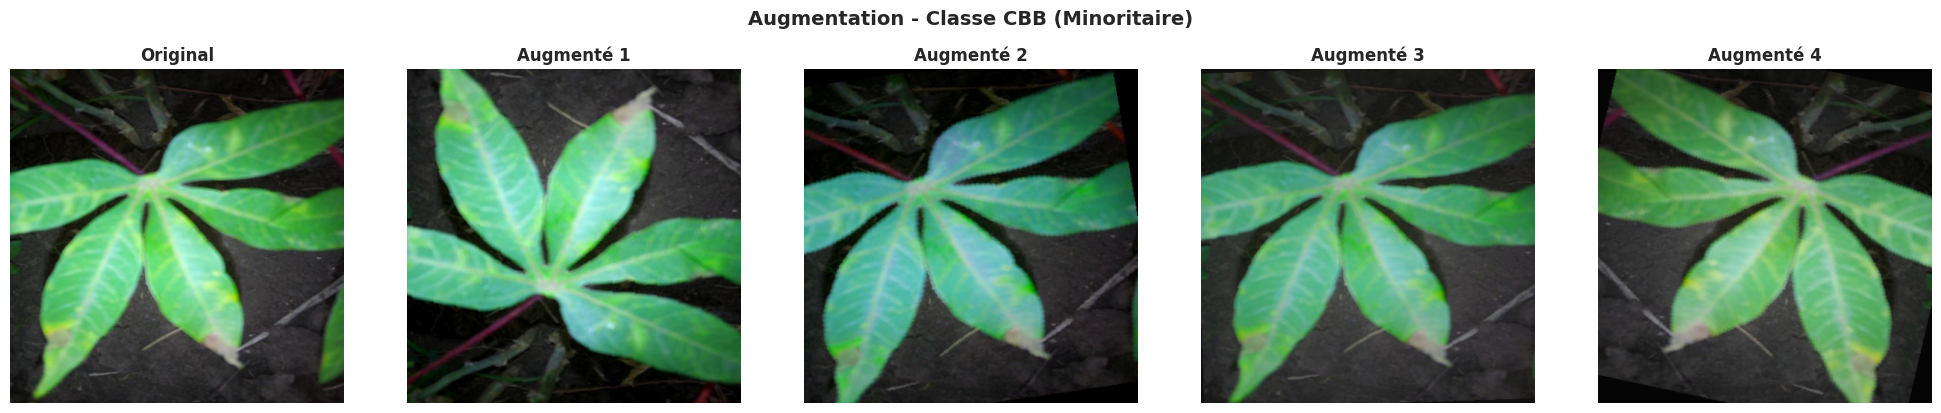

✓ Augmentation CBB visualisée et sauvegardée


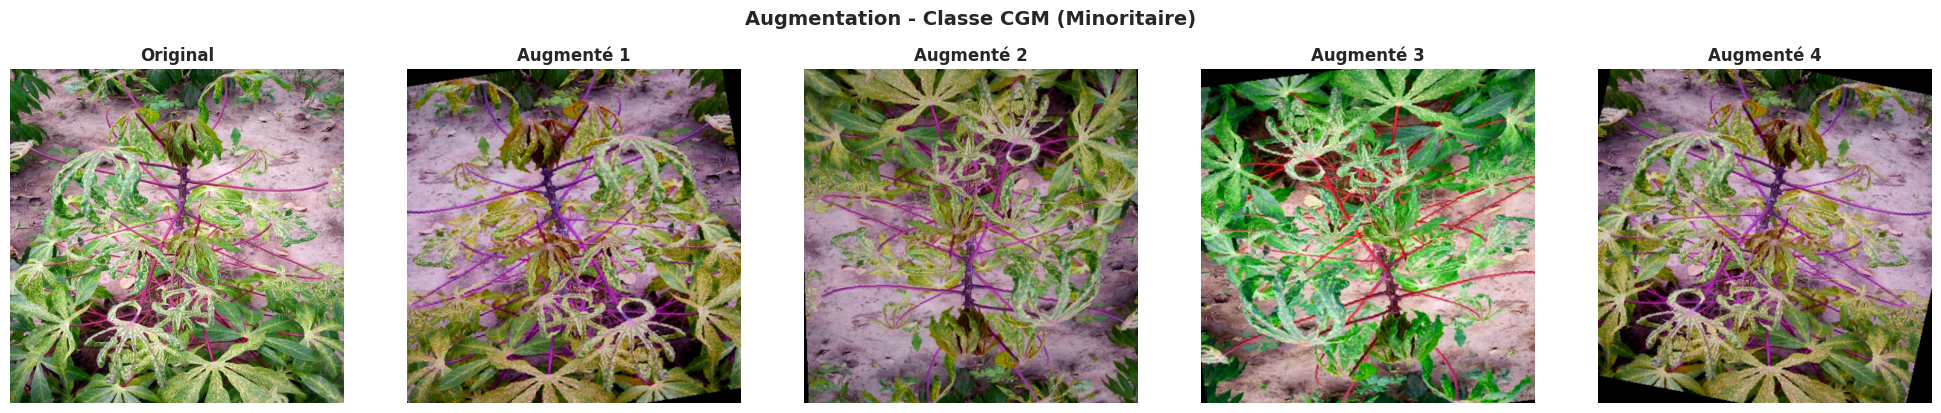

✓ Augmentation CGM visualisée et sauvegardée

✓ Toutes les augmentations visualisées


In [10]:
# Pour chaque classe minoritaire, montrer l'image originale + 4 versions augmentées
for class_name, img_path in sample_images.items():
    # Charger l'image
    img = Image.open(img_path).convert('RGB')
    
    # Créer figure
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    # Image originale
    axes[0].imshow(img)
    axes[0].set_title('Original', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # 4 versions augmentées
    for i in range(1, 5):
        # Appliquer les transformations
        augmented = augmentation_transforms(img)
        axes[i].imshow(augmented)
        axes[i].set_title(f'Augmenté {i}', fontsize=12, fontweight='bold')
        axes[i].axis('off')
    
    plt.suptitle(f'Augmentation - Classe {class_name} (Minoritaire)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / f'augmentation_{class_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Augmentation {class_name} visualisée et sauvegardée")

print("\n" + "="*70)
print("✓ Toutes les augmentations visualisées")
print("="*70)

## 11. Sauvegarde de la Configuration

In [11]:
# Configuration complète à sauvegarder
config = {
    'class_distribution': {
        class_short: {
            'label': info['label'],
            'count': info['count'],
            'percentage': info['percentage'],
            'name': info['name']
        }
        for class_short, info in dataset_info['class_distribution'].items()
    },
    'imbalance_stats': {
        'total_images': total,
        'majority_class': max_class,
        'majority_count': int(class_counts[max_class]),
        'minority_class': min_class,
        'minority_count': int(class_counts[min_class]),
        'imbalance_ratio': float(imbalance_ratio)
    },
    'class_weights': {
        int(label): float(weight) 
        for label, weight in weight_dict.items()
    },
    'augmentation_strategy': augmentation_strategy
}

# Sauvegarder en JSON
config_path = OUTPUTS_DIR / "augmentation_weights_config.json"
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

# Sauvegarder les class weights en format numpy pour chargement rapide
np.save(OUTPUTS_DIR / "class_weights.npy", class_weights)

# Sauvegarder le tensor PyTorch
torch.save(class_weights_tensor, OUTPUTS_DIR / "class_weights.pt")

print("="*70)
print("CONFIGURATION SAUVEGARDÉE")
print("="*70)
print(f"Fichiers créés:")
print(f"  - {config_path}")
print(f"  - {OUTPUTS_DIR / 'class_weights.npy'}")
print(f"  - {OUTPUTS_DIR / 'class_weights.pt'}")
print(f"  - {OUTPUTS_DIR / 'class_distribution.png'}")
print(f"  - {OUTPUTS_DIR / 'class_weights.png'}")
for class_name in sample_images.keys():
    print(f"  - {OUTPUTS_DIR / f'augmentation_{class_name}.png'}")
print("\n✓ Configuration complète sauvegardée")
print("="*70)

CONFIGURATION SAUVEGARDÉE
Fichiers créés:
  - /home/hounfodjidagba/learning/cassava/outputs/augmentation_weights/augmentation_weights_config.json
  - /home/hounfodjidagba/learning/cassava/outputs/augmentation_weights/class_weights.npy
  - /home/hounfodjidagba/learning/cassava/outputs/augmentation_weights/class_weights.pt
  - /home/hounfodjidagba/learning/cassava/outputs/augmentation_weights/class_distribution.png
  - /home/hounfodjidagba/learning/cassava/outputs/augmentation_weights/class_weights.png
  - /home/hounfodjidagba/learning/cassava/outputs/augmentation_weights/augmentation_CBB.png
  - /home/hounfodjidagba/learning/cassava/outputs/augmentation_weights/augmentation_CGM.png

✓ Configuration complète sauvegardée


## Résumé et Prochaines Étapes

### ✓ Accompli dans ce notebook:
1. **Analyse du déséquilibre** - Ratio 16.7:1 confirmé (CMD vs CBB)
2. **Class weights calculés** - Sklearn balanced weights
3. **Stratégie d'augmentation** - 5 techniques pour classes minoritaires
4. **Visualisations créées** - Distribution, weights, augmentations
5. **Configuration sauvegardée** - JSON, NPY, PT formats

### 🎯 Résultats clés:
- **Déséquilibre**: CMD (59.5%) vs CBB (3.6%) = 16.7:1
- **Class weights**: CBB=28.04, CMD=0.56 (ratio 50:1)
- **Classes cibles augmentation**: CBB, CGM (minoritaires)
- **Techniques**: Rotation, Flip H/V, Color Jitter, Random Crop

### 📋 Prochaines étapes (Notebook 11 - Training Phase 1):
1. Charger le modèle avec LoRA
2. Configurer weighted CrossEntropyLoss
3. Setup TensorBoard & WandB
4. Entraîner projecteur (1 epoch, ~3-4h)
5. Sauvegarder checkpoint Phase 1

### 📊 Impact attendu:
- **Weighted loss**: Compense le déséquilibre 16.7:1
- **Augmentation**: Améliore généralisation classes minoritaires
- **Target F1-score**: >90% pour toutes les classes (incluant CBB)
- **Accuracy globale**: >95% après fine-tuning